#Mobile App Addition Risk Predictor
by Deepak Otari (computer Engg.)

Project Title: **Mobile App Addiction Risk Predictor**

Description:
The Mobile App Addiction Risk Predictor is a machine learning project designed to estimate a user’s risk of developing mobile app addiction. By analyzing patterns in smartphone usage—such as screen time, frequency of app usage, and late-night activity—the model classifies users into risk categories (e.g., low, moderate, high). The system aims to support digital well-being by identifying unhealthy usage trends early and encouraging more balanced app usage.

**Key Characteristics:**

**Behavior-Based Prediction**

**Risk Level Classification**

**Supervised Machine Learning Model**

**Performance Evaluation**

**Scalable & Extensible**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Export the DataFrame to a CSV file
df = pd.read_csv('/content/mobile_addiction_data_enhanced.csv')

**CSV File Description:-**
The Mobile App Addiction Risk Predictor dataset is a comprehensive CSV file designed to analyze and predict the risk of mobile app addiction based on a wide range of demographic, behavioral, and psychological factors.

In this CSV Having a Total Columns: 30 and Total rows. : 1,000

### EDA Basic Data Inspection

In [ ]:
df.head()

In [ ]:
df.tail()

In [ ]:
df.sample(5)

,User_ID,Country,Age,Gender,Occupation,Education_Level,Income_USD,Daily_Screen_Time_Hours,Phone_Unlocks_Per_Day,Social_Media_Usage_Hours,...,Mental_Sum,Screen_Sleep_Ratio,Unlock_Rate,Screen_Minus_Sleep,Mental_x_Screen,Social_x_Mental,Age_Phone_Gap,Work_Life_Balance,Passive_Usage,Health_Screen
2454,2455,USA,53,Female,Artist,NaN,53232.88,5.58,89,1.65,...,151.31,0.732187,15.946963,-2.04,844.3098,249.6615,40,1.941639,3.69,382.7322
1752,1753,Japan,38,Male,Artist,Bachelor's,9612.68,6.80,80,0.60,...,171.79,1.449584,11.762976,2.11,1168.1720,103.0740,22,1.196341,3.64,568.6160
1402,1403,Mexico,38,Other,Engineer,Bachelor's,15505.97,7.48,103,-0.47,...,113.38,0.905459,13.768213,-0.78,848.0824,-53.2886,22,1.189454,0.89,521.8796
454,455,Nigeria,35,Other,Teacher,High School,16237.50,6.18,90,1.63,...,94.41,0.916778,14.560751,-0.56,583.4538,153.8883,24,0.177022,4.57,549.6492
758,759,Nigeria,67,Other,Artist,High School,37289.19,6.91,71,3.45,...,205.32,1.028121,10.273477,0.19,1418.7612,708.3540,58,-12.936803,7.02,466.0104


In [ ]:
df.shape

In [ ]:
df.columns

In [ ]:
# Data types + null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 52 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   User_ID                         3000 non-null   int64  
 1   Country                         3000 non-null   object 
 2   Age                             3000 non-null   int64  
 3   Gender                          3000 non-null   object 
 4   Occupation                      3000 non-null   object 
 5   Education_Level                 2388 non-null   object 
 6   Income_USD                      3000 non-null   float64
 7   Daily_Screen_Time_Hours         3000 non-null   float64
 8   Phone_Unlocks_Per_Day           3000 non-null   int64  
 9   Social_Media_Usage_Hours        3000 non-null   float64
 10  Gaming_Usage_Hours              3000 non-null   float64
 11  Streaming_Usage_Hours           3000 non-null   float64
 12  Messaging_Usage_Hours           30

In [ ]:

df.describe()

,User_ID,Age,Income_USD,Daily_Screen_Time_Hours,Phone_Unlocks_Per_Day,Social_Media_Usage_Hours,Gaming_Usage_Hours,Streaming_Usage_Hours,Messaging_Usage_Hours,Work_Related_Usage_Hours,...,Mental_Sum,Screen_Sleep_Ratio,Unlock_Rate,Screen_Minus_Sleep,Mental_x_Screen,Social_x_Mental,Age_Phone_Gap,Work_Life_Balance,Passive_Usage,Health_Screen
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,...,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,41.307333,29779.511047,5.984397,79.699667,1.988487,1.486617,1.981433,1.48917,1.995423,...,149.64587,0.944520,14.948975,-0.508317,893.943800,297.335544,27.353333,4.061458,3.969920,297.786637
std,866.169729,17.052345,15377.473743,2.018142,25.155683,0.983224,0.997255,1.004578,0.50883,0.972245,...,50.51871,0.359131,83.325327,2.243045,437.596249,184.279029,17.363669,60.040228,1.403787,205.303658
min,1.000000,12.000000,-25622.660000,-0.500000,-7.000000,-1.810000,-1.930000,-1.910000,-0.18000,-1.160000,...,5.11000,-0.085020,-2101.694915,-7.940000,-94.036800,-312.243100,-8.000000,-292.222222,-0.600000,-46.245000
25%,750.750000,27.000000,19482.705000,4.597500,63.000000,1.340000,0.810000,1.290000,1.14000,1.340000,...,114.08000,0.696315,9.550866,-2.032500,574.853050,167.917700,13.000000,0.768766,3.030000,130.055350
50%,1500.500000,42.000000,30002.710000,5.980000,80.000000,2.010000,1.510000,2.010000,1.50000,1.980000,...,148.98500,0.923895,13.355942,-0.495000,841.416000,276.149800,27.000000,1.300041,3.970000,269.277100
75%,2250.250000,56.000000,40352.017500,7.302500,96.000000,2.640000,2.180000,2.650000,1.84000,2.670000,...,185.24500,1.167552,18.408944,1.020000,1151.511225,399.960600,42.000000,2.136877,4.930000,436.826325
max,3000.000000,70.000000,79829.550000,12.870000,182.000000,5.050000,4.860000,5.180000,3.07000,5.260000,...,293.95000,2.674108,2129.032258,7.520000,3174.884200,1270.165200,62.000000,2370.000000,9.080000,1169.337600


In [ ]:
df.dtypes

,0
User_ID,int64
Country,object
Age,int64
Gender,object
Occupation,object
Education_Level,object
Income_USD,float64
Daily_Screen_Time_Hours,float64
Phone_Unlocks_Per_Day,int64
Social_Media_Usage_Hours,float64


##Data Cleaning






In [ ]:
df.isnull().sum()

,0
User_ID,0
Country,0
Age,0
Gender,0
Occupation,0
Education_Level,612
Income_USD,0
Daily_Screen_Time_Hours,0
Phone_Unlocks_Per_Day,0
Social_Media_Usage_Hours,0


In [ ]:
# Identify numerical columns that should not have negative values
columns_to_clip = [
    'Income_USD',
    'Daily_Screen_Time_Hours',
    'Phone_Unlocks_Per_Day',
    'Social_Media_Usage_Hours',
    'Gaming_Usage_Hours',
    'Streaming_Usage_Hours',
    'Messaging_Usage_Hours',
    'Work_Related_Usage_Hours',
    'Sleep_Hours',
    'Physical_Activity_Hours',
    'Time_Spent_With_Family_Hours',
    'Online_Shopping_Hours',
    'Monthly_Data_Usage_GB',
    'Push_Notifications_Per_Day'
]

# Clip negative values to 0
for col in columns_to_clip:
    if col in df.columns:
        df[col] = df[col].clip(lower=0)

# Impute missing values in 'Education_Level' with the mode
if 'Education_Level' in df.columns:
    mode_education = df['Education_Level'].mode()[0]
    df['Education_Level'] = df['Education_Level'].fillna(mode_education)

# Display the count of missing values after imputation to confirm
print("Missing values after handling:\n", df.isnull().sum())

Missing values after handling:
 User_ID                           0
Country                           0
Age                               0
Gender                            0
Occupation                        0
Education_Level                   0
Income_USD                        0
Daily_Screen_Time_Hours           0
Phone_Unlocks_Per_Day             0
Social_Media_Usage_Hours          0
Gaming_Usage_Hours                0
Streaming_Usage_Hours             0
Messaging_Usage_Hours             0
Work_Related_Usage_Hours          0
Sleep_Hours                       0
Physical_Activity_Hours           0
Mental_Health_Score               0
Depression_Score                  0
Anxiety_Score                     0
Stress_Level                      0
Relationship_Status               0
Has_Children                      0
Urban_or_Rural                    0
Time_Spent_With_Family_Hours      0
Online_Shopping_Hours             0
Internet_Connection_Type          0
Primary_Device_Brand            

In [ ]:
df.count()

,0
User_ID,3000
Country,3000
Age,3000
Gender,3000
Occupation,3000
Education_Level,3000
Income_USD,3000
Daily_Screen_Time_Hours,3000
Phone_Unlocks_Per_Day,3000
Social_Media_Usage_Hours,3000


####This counts non-null values in each column

In [ ]:
df.dropna()

,User_ID,Country,Age,Gender,Occupation,Education_Level,Income_USD,Daily_Screen_Time_Hours,Phone_Unlocks_Per_Day,Social_Media_Usage_Hours,...,Mental_Sum,Screen_Sleep_Ratio,Unlock_Rate,Screen_Minus_Sleep,Mental_x_Screen,Social_x_Mental,Age_Phone_Gap,Work_Life_Balance,Passive_Usage,Health_Screen
0,1,India,32,Male,Salesperson,High School,43865.49,5.81,75,0.84,...,200.32,1.112814,12.906557,0.59,1163.8592,168.2688,16,1.258083,4.20,357.1407
1,2,UK,26,Male,Artist,Master's,41868.19,9.05,61,3.13,...,163.74,1.452415,6.739587,2.82,1481.8470,512.5062,14,1.598224,3.93,869.7955
2,3,Germany,70,Other,Doctor,High School,59636.51,5.76,58,2.12,...,238.65,0.876579,10.067697,-0.81,1374.6240,505.9380,52,1.135423,3.96,424.3968
3,4,UK,44,Female,Engineer,High School,39022.07,6.71,80,1.60,...,82.41,0.922844,11.920727,-0.56,552.9711,131.8560,27,1.638164,3.50,358.4482
4,5,Brazil,46,Other,Student,High School,0.00,6.31,136,1.51,...,69.55,1.161849,21.549675,0.88,438.8605,105.0205,28,1.658812,2.99,422.8331
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,Brazil,35,Male,Teacher,High School,36912.82,7.01,41,2.88,...,161.68,0.972126,5.847953,-0.20,1133.3768,465.6384,22,7.345309,5.31,264.4873
2996,2997,Russia,51,Male,Doctor,High School,21820.27,6.26,63,2.10,...,98.15,0.903189,10.062290,-0.67,614.4190,206.1150,36,0.510367,3.48,350.6226
2997,2998,USA,21,Female,Engineer,High School,30689.98,3.45,19,0.28,...,157.26,0.517940,5.505651,-3.21,542.5470,44.0328,4,0.950049,1.51,48.8865
2998,2999,Germany,43,Female,Salesperson,High School,16880.54,2.62,71,1.19,...,220.82,0.445502,27.088897,-3.26,578.5484,262.7758,32,3.672525,3.27,149.2614


In [ ]:
#Duplicate Values
df.duplicated().sum()
df.drop_duplicates(inplace=True)

Statistical Analysis

In [ ]:
df.min(numeric_only=True)
df.max(numeric_only=True)
df.max(numeric_only=True) - df.min(numeric_only=True)

,0
User_ID,2999.000000
Age,58.000000
Income_USD,79829.550000
Daily_Screen_Time_Hours,12.870000
Phone_Unlocks_Per_Day,182.000000
Social_Media_Usage_Hours,5.050000
Gaming_Usage_Hours,4.860000
Streaming_Usage_Hours,5.180000
Messaging_Usage_Hours,3.070000
Work_Related_Usage_Hours,5.260000


In [ ]:
df.skew(numeric_only=True)
df.kurtosis(numeric_only=True)

,0
User_ID,-1.200000
Age,-1.197823
Income_USD,-0.379706
Daily_Screen_Time_Hours,-0.043378
Phone_Unlocks_Per_Day,0.122435
Social_Media_Usage_Hours,-0.227571
Gaming_Usage_Hours,-0.490138
Streaming_Usage_Hours,-0.332813
Messaging_Usage_Hours,-0.162677
Work_Related_Usage_Hours,-0.281706


In [ ]:
df.corr(numeric_only=True)
df.cov(numeric_only=True)

,User_ID,Age,Income_USD,Daily_Screen_Time_Hours,Phone_Unlocks_Per_Day,Social_Media_Usage_Hours,Gaming_Usage_Hours,Streaming_Usage_Hours,Messaging_Usage_Hours,Work_Related_Usage_Hours,...,Mental_Sum,Screen_Sleep_Ratio,Unlock_Rate,Screen_Minus_Sleep,Mental_x_Screen,Social_x_Mental,Age_Phone_Gap,Work_Life_Balance,Passive_Usage,Health_Screen
User_ID,750250.000000,-229.470824,-3.756399e+05,-43.005008,-79.004335,12.758114,6.627733,-18.608806,-1.078213,5.744388,...,1035.524760,-6.427436,370.802919,-48.901155,-425.038742,4976.669501,-216.712237,-369.698334,-5.784628,-2334.619298
Age,-229.470824,290.782474,3.627860e+03,0.078739,3.533430,-0.270360,-0.149537,-0.038663,0.023297,-0.493992,...,13.557935,-0.017152,2.296164,-0.229200,27.580784,-8.358893,289.160129,6.235789,-0.327951,2.797606
Income_USD,-375639.886964,3627.859543,2.247660e+08,404.628134,-13517.437712,-524.334610,231.295885,-272.955997,-299.716736,-11.766987,...,15414.578401,42.340147,-28347.624193,329.937454,183839.071879,-29225.314365,5499.220531,-1897.856644,-802.250825,-6253.651361
Daily_Screen_Time_Hours,-43.005008,0.078739,4.046281e+02,4.063972,-0.072258,-0.006899,0.030624,0.010073,0.009997,-0.002327,...,-1.579757,0.642357,-10.078205,4.054017,597.372948,-3.532805,0.039894,2.436094,0.001251,191.311526
Phone_Unlocks_Per_Day,-79.004335,3.533430,-1.351744e+04,-0.072258,632.420003,0.800224,0.447221,-0.024779,0.013182,0.280188,...,39.722930,-0.043809,68.360559,-0.051102,230.353176,235.416797,1.585155,-30.339112,0.812780,4.968499
Social_Media_Usage_Hours,12.758114,-0.270360,-5.243346e+02,-0.006899,0.800224,0.929015,0.015130,-0.000274,-0.011288,0.010993,...,-0.261049,-0.002142,-2.720934,-0.015891,-1.884315,140.664160,-0.177881,0.941965,0.943808,-4.219559
Gaming_Usage_Hours,6.627733,-0.149537,2.312959e+02,0.030624,0.447221,0.015130,0.874573,0.030201,0.014513,-0.007180,...,1.565861,0.005920,0.397514,0.041035,15.056295,5.274194,-0.154777,-1.455122,0.046898,-1.514949
Streaming_Usage_Hours,-18.608806,-0.038663,-2.729560e+02,0.010073,-0.024779,-0.000274,0.030201,0.962657,0.015653,-0.008028,...,-1.076908,0.002448,-0.181479,0.006697,-10.347092,-2.276899,-0.108176,0.121253,0.980810,3.635046
Messaging_Usage_Hours,-1.078213,0.023297,-2.997167e+02,0.009997,0.013182,-0.011288,0.014513,0.015653,0.258540,0.004562,...,-0.014832,0.003162,-0.638513,0.019092,1.067414,-2.026187,0.019082,0.231020,0.004622,-1.227774
Work_Related_Usage_Hours,5.744388,-0.493992,-1.176699e+01,-0.002327,0.280188,0.010993,-0.007180,-0.008028,0.004562,0.909583,...,0.060296,0.001945,2.119743,0.007020,1.872266,2.024541,-0.476997,0.452989,0.005463,-3.104483


In [ ]:
cols_to_drop = [
    "User_ID",
    "Gender",
    "Location",
    "Primary_Use",
    "Age_First_Phone",
    "Phone_Usage_Purpose"
]

# Adding errors='ignore' ensures the code runs even if some column names don't match exactly
df.drop(cols_to_drop, axis=1, inplace=True, errors='ignore')

In [ ]:
df = df[df["Daily_Screen_Time_Hours"] <= 20]
df = df[df["Sleep_Hours"] >= 2]
df = df[df["Phone_Unlocks_Per_Day"] <= 300]
df = df[df["Push_Notifications_Per_Day"] <= 500]

Z-Score(Outlier Detections)

In [ ]:
import numpy as np
from scipy.stats import zscore

In [ ]:
numeric_cols = df.select_dtypes(include=np.number)

z_scores = np.abs(zscore(numeric_cols))

threshold = 3
outliers = (z_scores > threshold)

Apply Z-Score to Detect all Outliers from csv file

In [ ]:
print("Total Outliers Found:", outliers.sum().sum())

Total Outliers Found: 233


 Count Outliers from csv file

In [ ]:
df_clean = df[(z_scores < threshold).all(axis=1)]

Remove Outlier

In [ ]:
df

,Country,Age,Occupation,Education_Level,Income_USD,Daily_Screen_Time_Hours,Phone_Unlocks_Per_Day,Social_Media_Usage_Hours,Gaming_Usage_Hours,Streaming_Usage_Hours,...,Mental_Sum,Screen_Sleep_Ratio,Unlock_Rate,Screen_Minus_Sleep,Mental_x_Screen,Social_x_Mental,Age_Phone_Gap,Work_Life_Balance,Passive_Usage,Health_Screen
0,India,32,Salesperson,High School,43865.49,5.81,75,0.84,0.00,3.36,...,200.32,1.112814,12.906557,0.59,1163.8592,168.2688,16,1.258083,4.20,357.1407
1,UK,26,Artist,Master's,41868.19,9.05,61,3.13,2.50,0.80,...,163.74,1.452415,6.739587,2.82,1481.8470,512.5062,14,1.598224,3.93,869.7955
2,Germany,70,Doctor,High School,59636.51,5.76,58,2.12,1.96,1.84,...,238.65,0.876579,10.067697,-0.81,1374.6240,505.9380,52,1.135423,3.96,424.3968
3,UK,44,Engineer,High School,39022.07,6.71,80,1.60,2.70,1.90,...,82.41,0.922844,11.920727,-0.56,552.9711,131.8560,27,1.638164,3.50,358.4482
4,Brazil,46,Student,High School,0.00,6.31,136,1.51,1.73,1.48,...,69.55,1.161849,21.549675,0.88,438.8605,105.0205,28,1.658812,2.99,422.8331
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,Brazil,35,Teacher,High School,36912.82,7.01,41,2.88,0.85,2.43,...,161.68,0.972126,5.847953,-0.20,1133.3768,465.6384,22,7.345309,5.31,264.4873
2996,Russia,51,Doctor,High School,21820.27,6.26,63,2.10,1.12,1.38,...,98.15,0.903189,10.062290,-0.67,614.4190,206.1150,36,0.510367,3.48,350.6226
2997,USA,21,Engineer,High School,30689.98,3.45,19,0.28,1.25,1.23,...,157.26,0.517940,5.505651,-3.21,542.5470,44.0328,4,0.950049,1.51,48.8865
2998,Germany,43,Salesperson,High School,16880.54,2.62,71,1.19,1.51,2.08,...,220.82,0.445502,27.088897,-3.26,578.5484,262.7758,32,3.672525,3.27,149.2614


In [59]:
Q1 = df['Daily_Screen_Time_Hours'].quantile(0.25)
Q3 = df['Daily_Screen_Time_Hours'].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[(df['Daily_Screen_Time_Hours'] >= Q1 - 1.5*IQR) &
              (df['Daily_Screen_Time_Hours'] <= Q3 + 1.5*IQR)]

Data Visualization

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid")

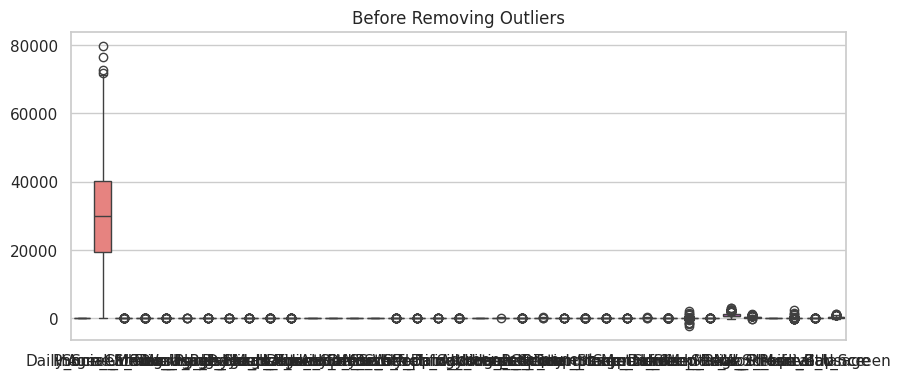

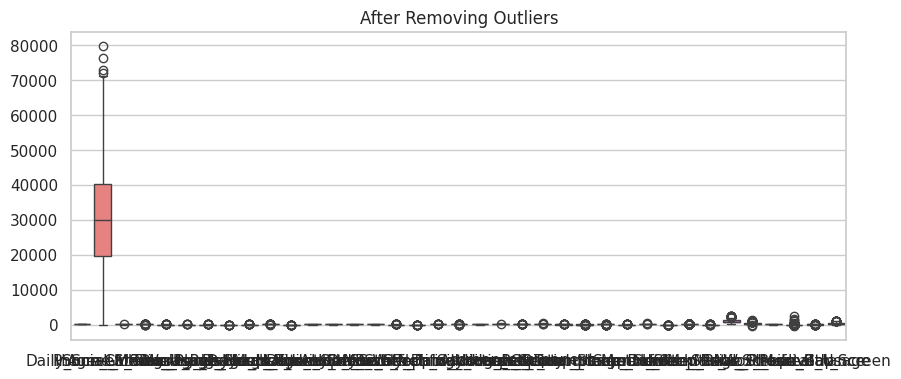

In [ ]:
plt.figure(figsize=(10,4))
sns.boxplot(data=numeric_cols)
plt.title("Before Removing Outliers")
plt.show()

plt.figure(figsize=(10,4))
sns.boxplot(data=df_clean.select_dtypes(include=np.number))
plt.title("After Removing Outliers")
plt.show()

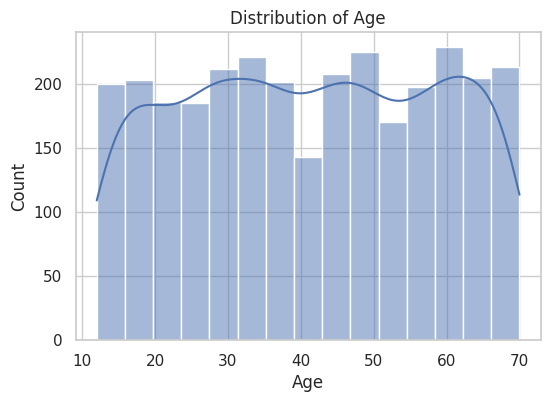

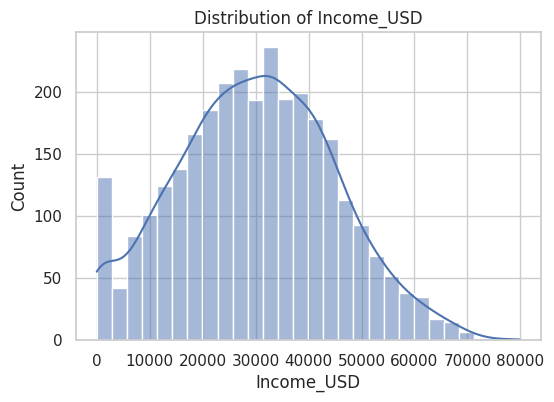

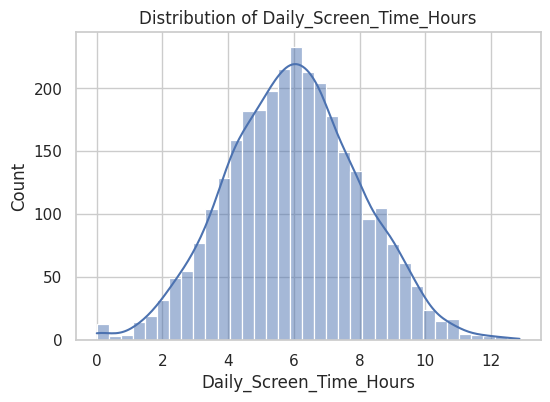

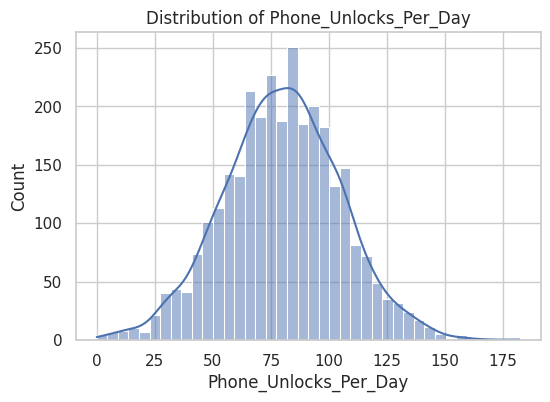

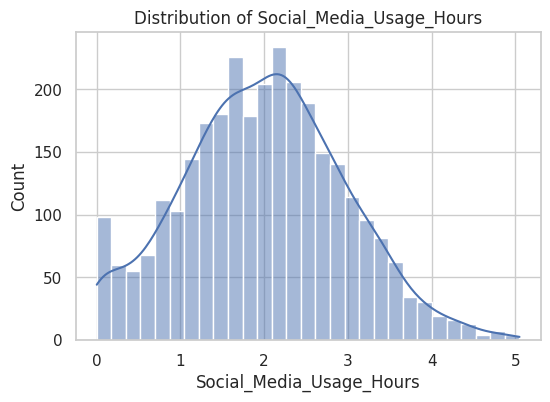

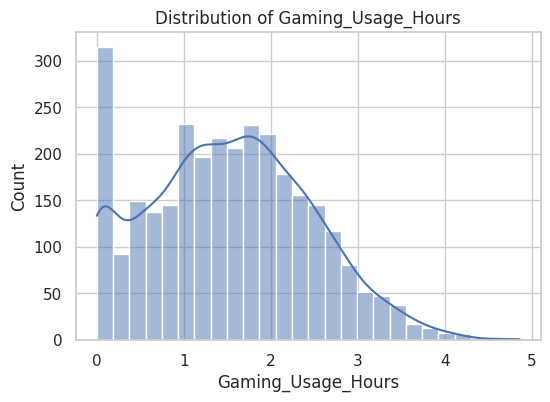

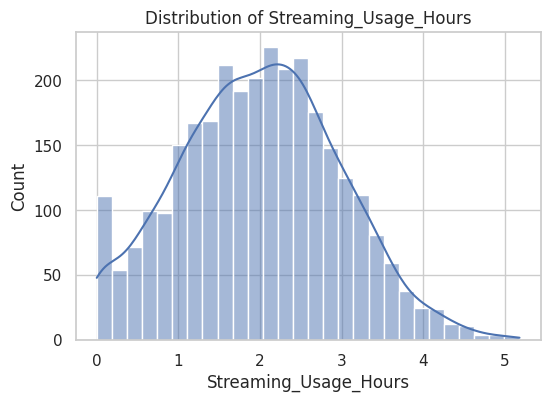

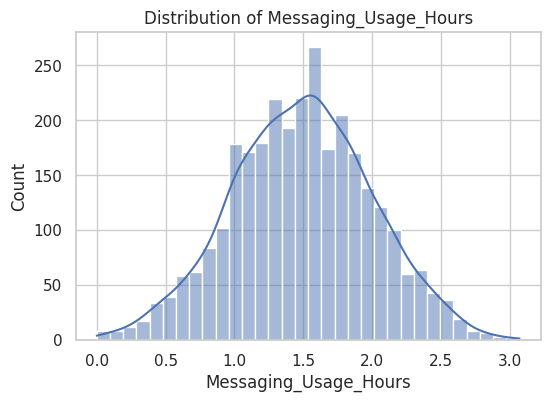

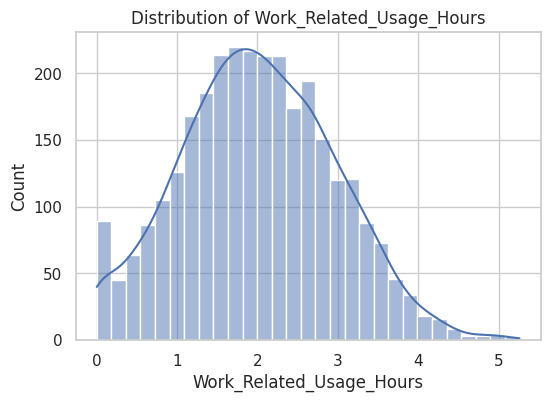

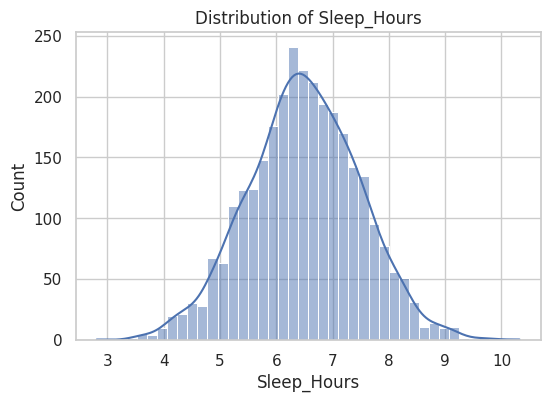

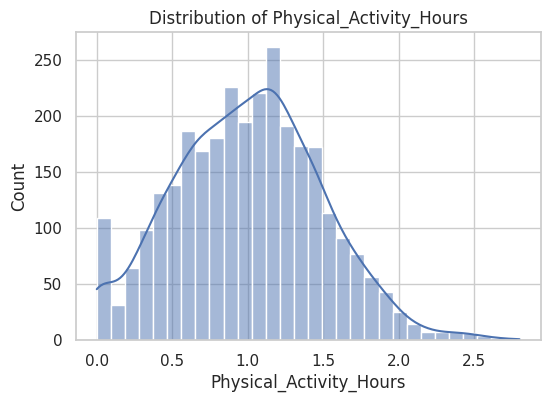

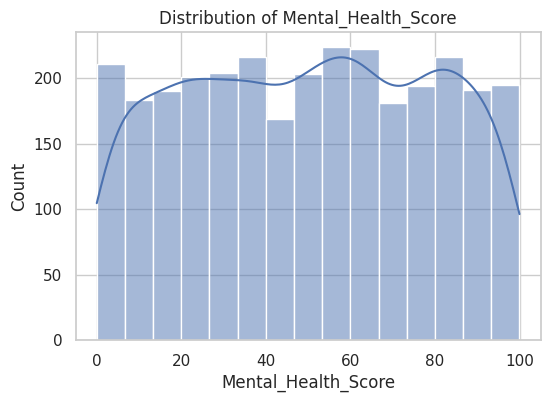

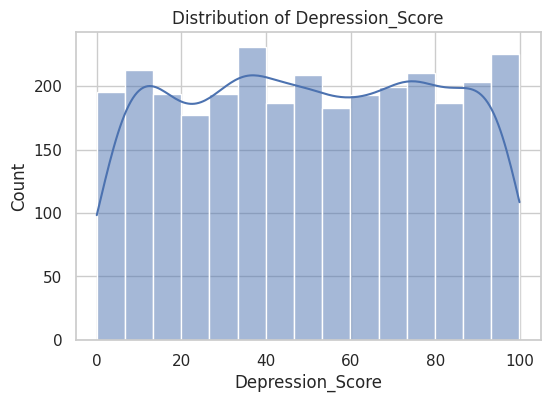

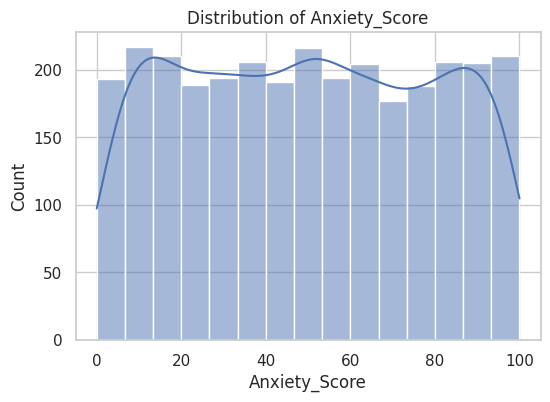

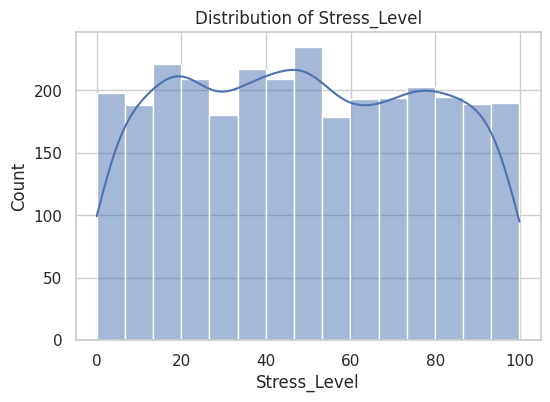

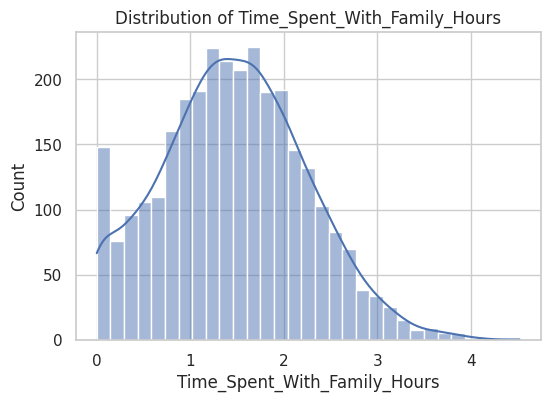

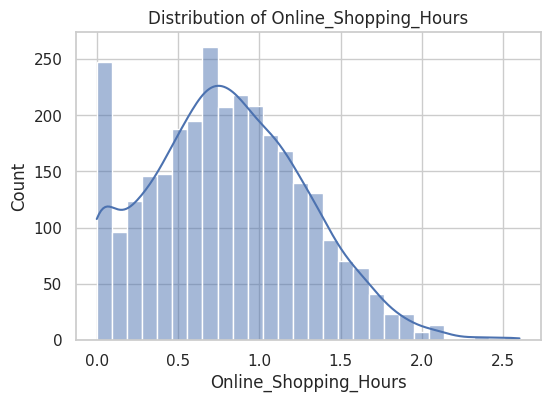

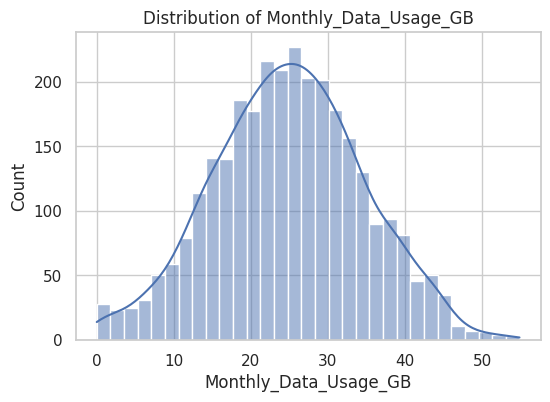

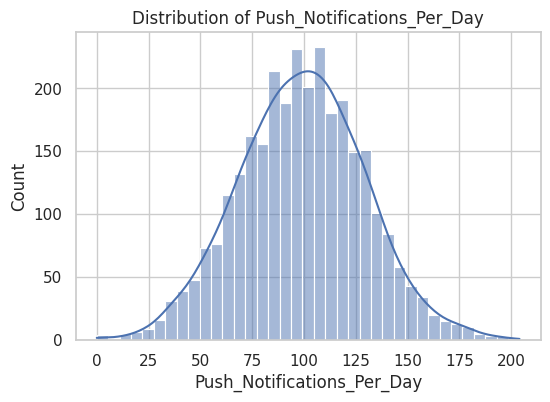

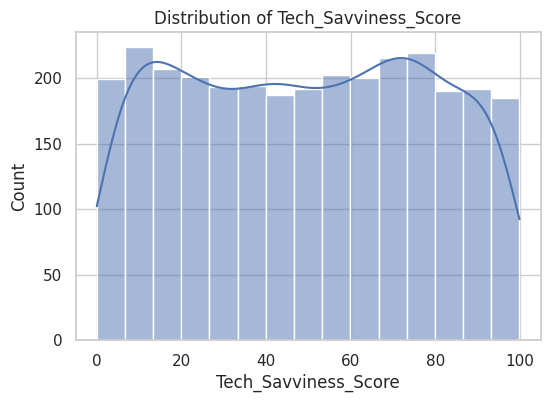

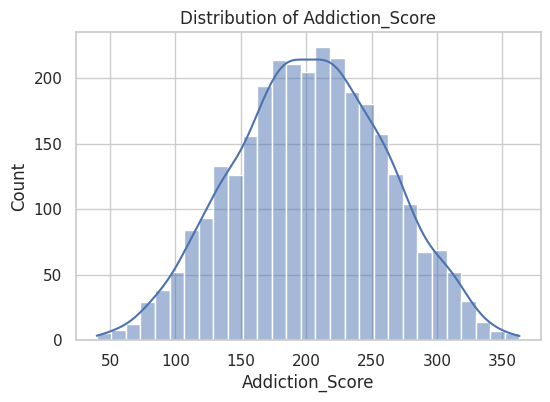

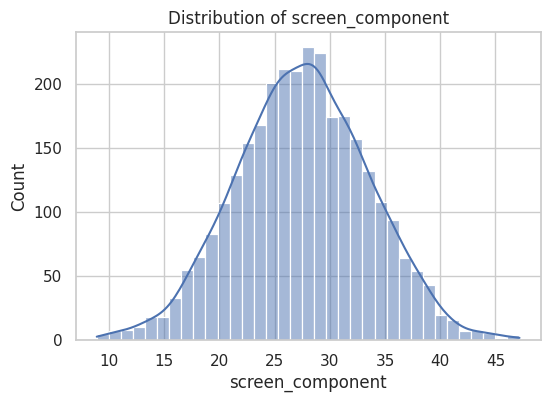

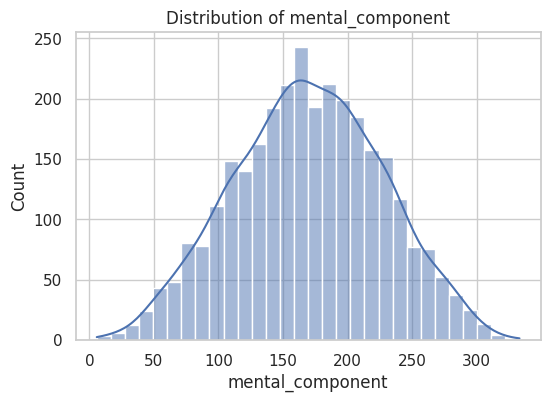

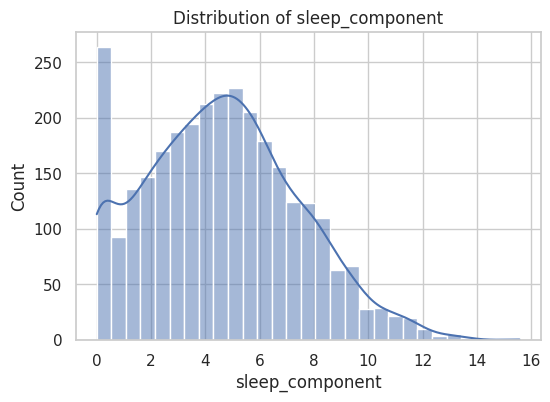

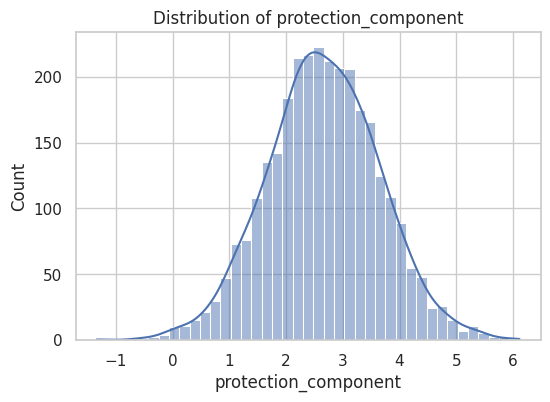

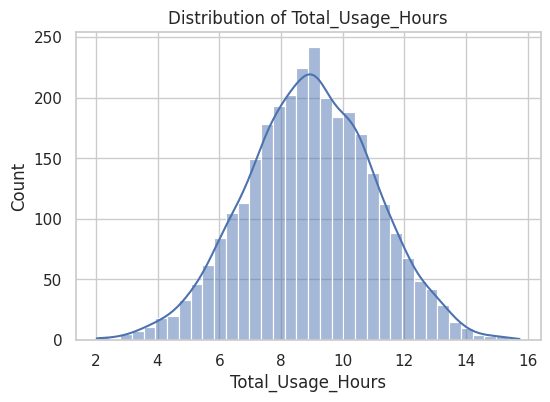

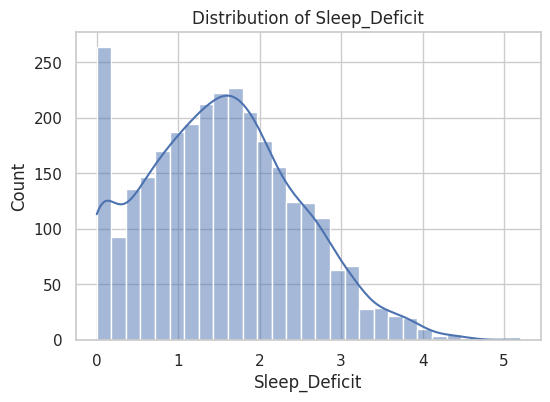

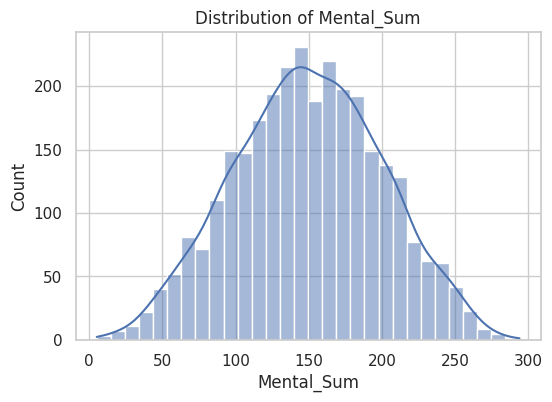

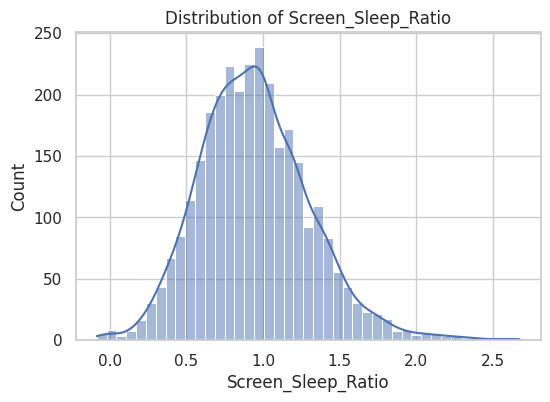

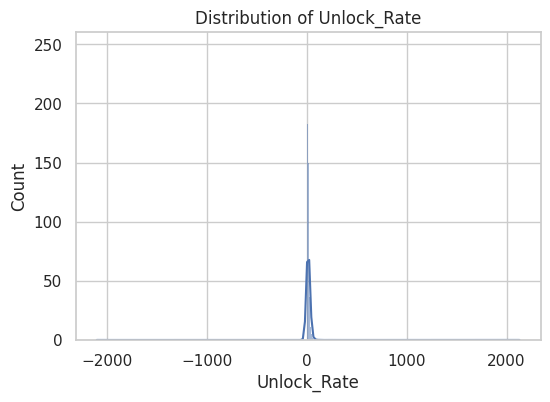

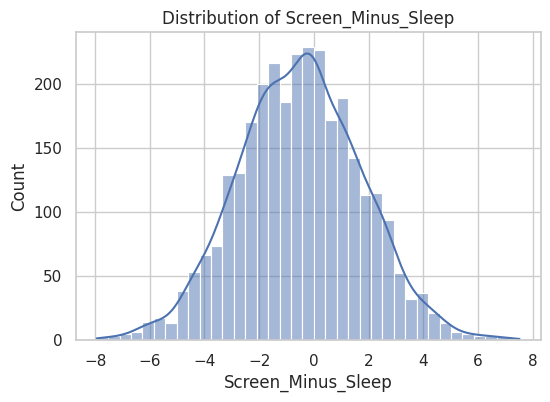

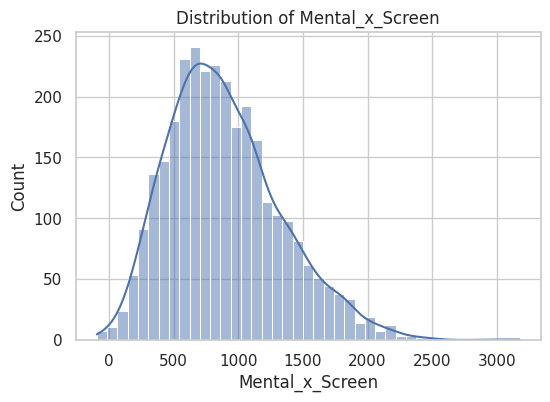

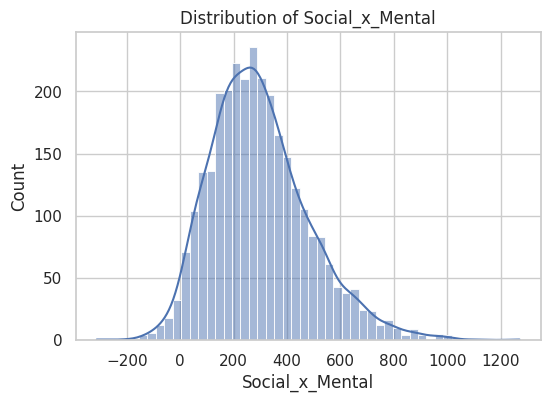

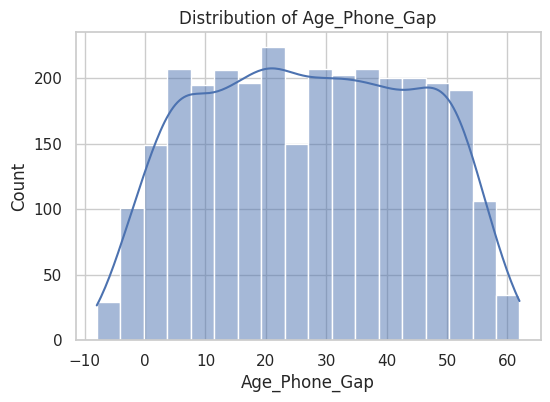

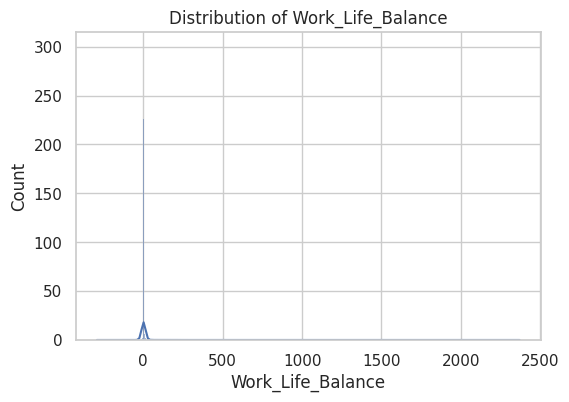

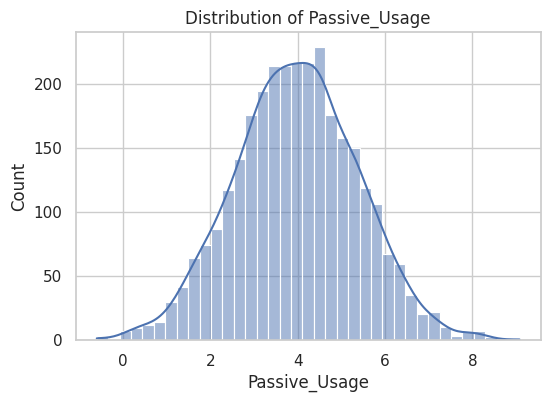

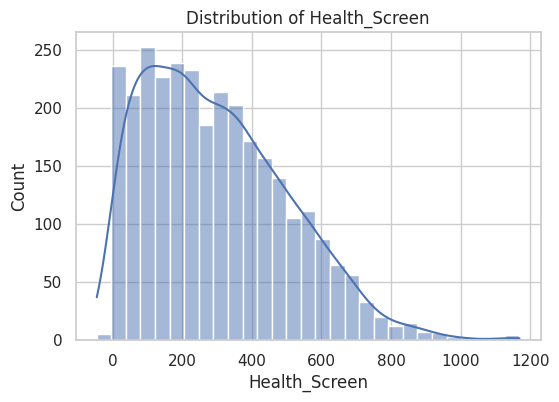

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

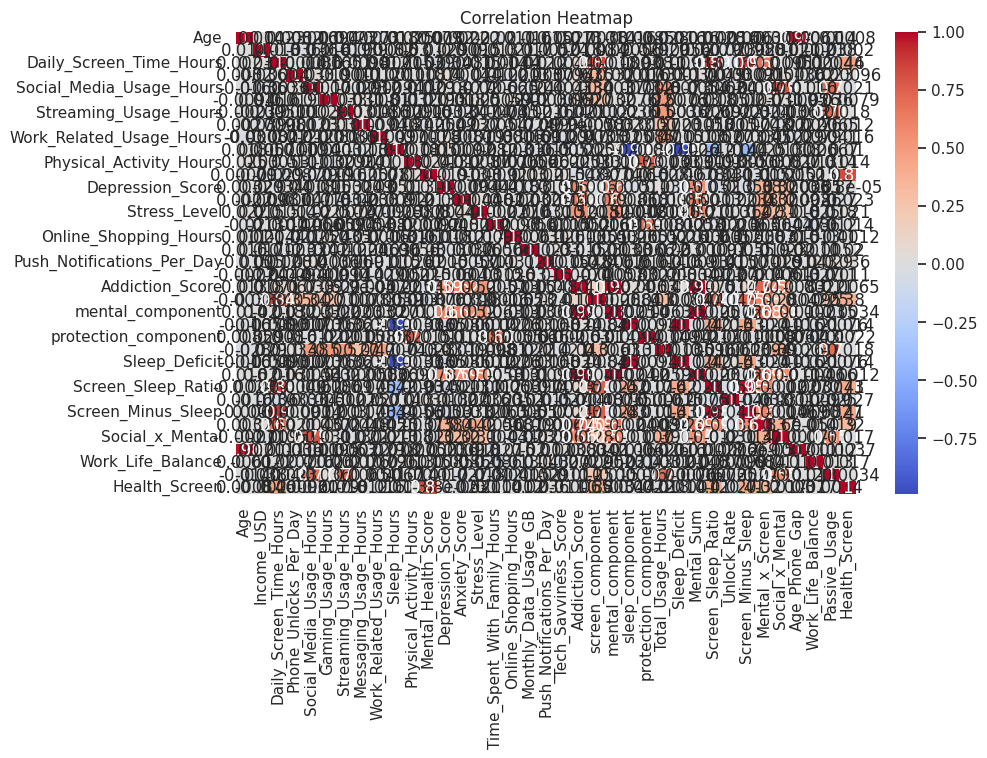

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

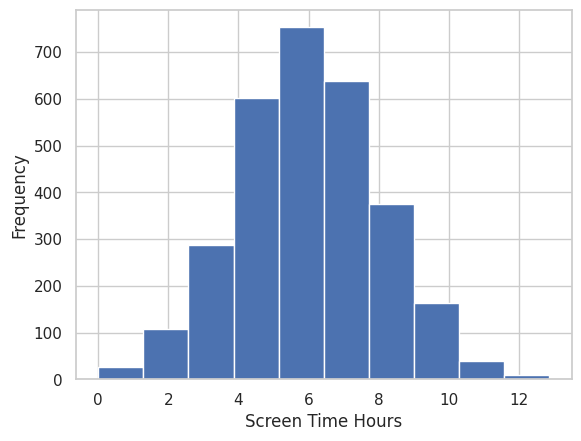

In [ ]:
# Histogram
plt.hist(df['Daily_Screen_Time_Hours'])
plt.xlabel("Screen Time Hours")
plt.ylabel("Frequency")
plt.show()

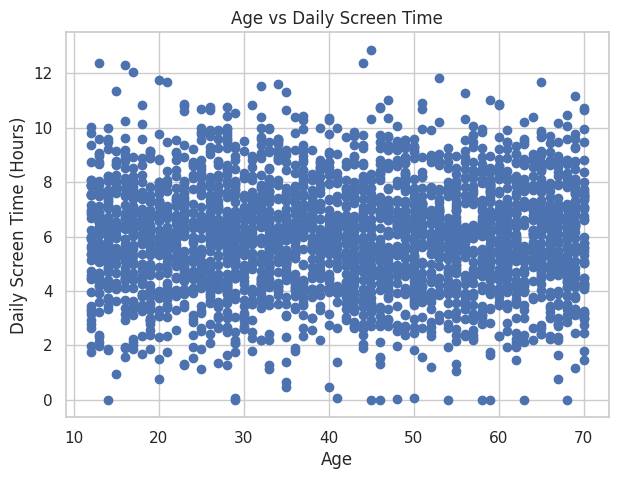

In [ ]:
# Scatter plot
plt.figure(figsize=(7,5))
plt.scatter(df['Age'], df['Daily_Screen_Time_Hours'])
plt.xlabel("Age")
plt.ylabel("Daily Screen Time (Hours)")
plt.title("Age vs Daily Screen Time")
plt.show()

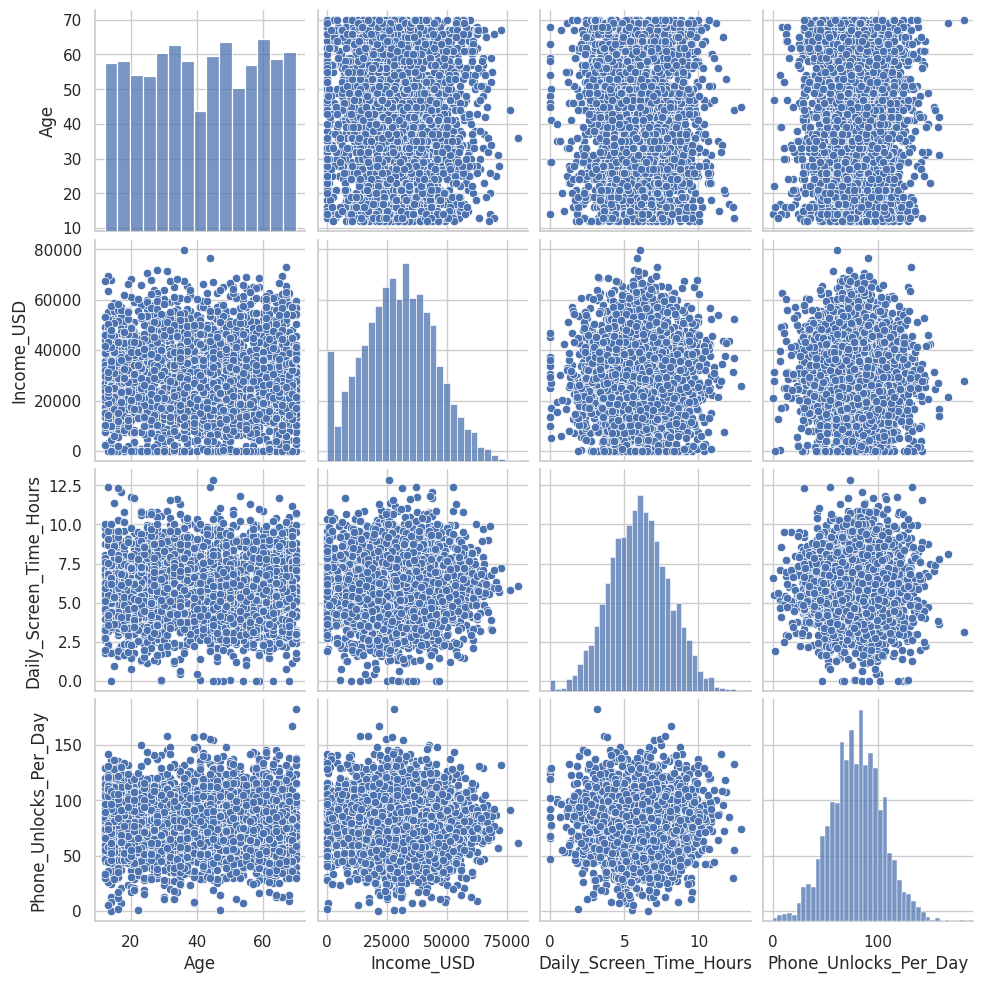

In [ ]:
sns.pairplot(df[num_cols[:4]])
plt.show()

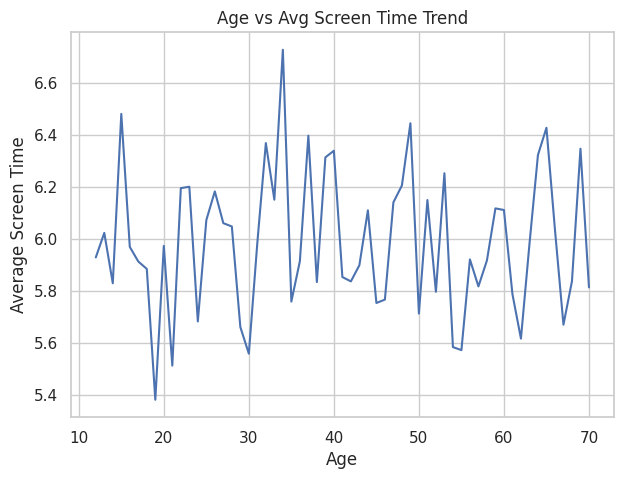

In [ ]:
#Line Plot
avg_data = df.groupby('Age')['Daily_Screen_Time_Hours'].mean()

plt.figure(figsize=(7,5))
plt.plot(avg_data.index, avg_data.values)
plt.xlabel("Age")
plt.ylabel("Average Screen Time")
plt.title("Age vs Avg Screen Time Trend")
plt.show()

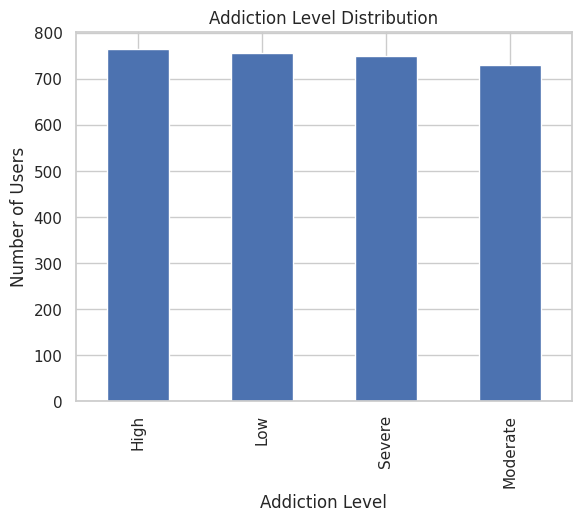

In [ ]:
# Bar Chart
df['Self_Reported_Addiction_Level'].value_counts().plot(kind='bar')

plt.xlabel("Addiction Level")
plt.ylabel("Number of Users")
plt.title("Addiction Level Distribution")
plt.show()

#Machine Learning

It's subset of artificial intelligence (AI) focused on building systems that learn from data to improve performance or make predictions without being explicitly programmed for every task

###Prepare Data for Model Training

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [ ]:
df = pd.read_csv('/content/mobile_addiction_data_enhanced.csv')

In [ ]:
# Identify numerical columns that should not have negative values
columns_to_clip = [
    'Income_USD',
    'Daily_Screen_Time_Hours',
    'Phone_Unlocks_Per_Day',
    'Social_Media_Usage_Hours',
    'Gaming_Usage_Hours',
    'Streaming_Usage_Hours',
    'Messaging_Usage_Hours',
    'Work_Related_Usage_Hours',
    'Sleep_Hours',
    'Physical_Activity_Hours',
    'Time_Spent_With_Family_Hours',
    'Online_Shopping_Hours',
    'Monthly_Data_Usage_GB',
    'Push_Notifications_Per_Day'
]

# Clip negative values to 0
for col in columns_to_clip:
    if col in df.columns:
        df[col] = df[col].clip(lower=0)

# Impute missing values in 'Education_Level' with the mode
if 'Education_Level' in df.columns:
    mode_education = df['Education_Level'].mode()[0]
    df['Education_Level'] = df['Education_Level'].fillna(mode_education)

print("Data cleaned: negative values clipped and missing Education_Level imputed.")

Data cleaned: negative values clipped and missing Education_Level imputed.


Take a Separate the Prediction Target (y) from the Features (X)

X is all the data we use to predict

y is the answer we want to find (Addiction Level)

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

# Define features (X) and target (y)
# Use errors='ignore' because 'User_ID' might have been dropped in previous EDA cells
X = df.drop(['User_ID', 'Self_Reported_Addiction_Level'], axis=1, errors='ignore')
y = df['Self_Reported_Addiction_Level']

# Encode the target variable 'Self_Reported_Addiction_Level'
le_y = LabelEncoder()
y_encoded = le_y.fit_transform(y)
print(f"Target variable 'Self_Reported_Addiction_Level' encoded. Classes: {le_y.classes_}")

# Identify categorical and numerical columns in X for preprocessing
categorical_features = X.select_dtypes(include='object').columns
numerical_features = X.select_dtypes(include=np.number).columns

# Create a column transformer to apply different preprocessing steps to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ],
    remainder='passthrough'
)

# Apply the preprocessing to the feature set X
X_processed = preprocessor.fit_transform(X)

# Split the preprocessed data
X_train, X_test, y_train, y_test = train_test_split(X_processed, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print("Data preprocessed successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

Target variable 'Self_Reported_Addiction_Level' encoded. Classes: ['High' 'Low' 'Moderate' 'Severe']
Data preprocessed successfully.
X_train shape: (2400, 77)
y_train shape: (2400,)


In [ ]:
# This cell is being removed as its `X` and `y` definition was incorrect and is now handled in `kjp8U2OaUQiO`.

## Identify Categorical Features for One-Hot Encoding

### Subtask:
Identify all non-numeric (object dtype) columns in the `X_train` and `X_test` DataFrames that need to be converted into numerical format using one-hot encoding. This is crucial because machine learning models and `StandardScaler` expect numerical inputs.


**Reasoning**:
To identify categorical features, I need to select columns with the 'object' datatype from the `X_train` DataFrame.



In [ ]:
categorical_cols = X.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", categorical_cols)

Categorical columns: ['Country', 'Gender', 'Occupation', 'Education_Level', 'Relationship_Status', 'Has_Children', 'Urban_or_Rural', 'Internet_Connection_Type', 'Primary_Device_Brand', 'Has_Screen_Time_Management_App', 'Has_Night_Mode_On', 'Addiction_Label_Rebuilt']


**Reasoning**:
Now that categorical columns have been identified, the next step is to apply one-hot encoding to convert these non-numeric columns into a numerical format, which is required for machine learning models and scaling. Additionally, the target variable `y` needs to be encoded numerically. After encoding, the columns in `X_train` and `X_test` must be aligned to ensure consistency before scaling. Finally, `StandardScaler` will be applied to the encoded and aligned features.



###Train a Classification Model

Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

# Instantiate the LogisticRegression model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


**Reasoning**:
To train a classification model, I need to import the `LogisticRegression` model from `sklearn.linear_model`, instantiate it with a specified `random_state`, and then fit it to the scaled training data and encoded target variable.



**Reasoning**:
Now that the model has been trained, the next logical step is to evaluate its performance on the test data. This involves making predictions on the scaled test set and then computing evaluation metrics.



### Hyperparameter Tuning for Logistic Regression


In [57]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Define the parameter grid for Logistic Regression
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'],
    'penalty': ['l1', 'l2']
}

# Instantiate GridSearchCV
grid_search = GridSearchCV(LogisticRegression(random_state=42, max_iter=1000), param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters for Logistic Regression:", grid_search.best_params_)
print("Best cross-validation accuracy for Logistic Regression:", grid_search.best_score_)

# Get the best model
best_lr_model = grid_search.best_estimator_

# Make predictions with the best model
y_pred_lr_tuned = best_lr_model.predict(X_test)

# Evaluate the best model
lr_tuned_accuracy = accuracy_score(y_test, y_pred_lr_tuned)
lr_tuned_conf_matrix = confusion_matrix(y_test, y_pred_lr_tuned)
lr_tuned_class_report = classification_report(y_test, y_pred_lr_tuned)

print(f"\nTuned Logistic Regression Accuracy: {lr_tuned_accuracy:.2f}")
print("\nTuned Logistic Regression Confusion Matrix:\n", lr_tuned_conf_matrix)
print("\nTuned Logistic Regression Classification Report:\n", lr_tuned_class_report)

Best parameters for Logistic Regression: {'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-validation accuracy for Logistic Regression: 0.2779166666666667

Tuned Logistic Regression Accuracy: 0.29

Tuned Logistic Regression Confusion Matrix:
 [[42 42 37 32]
 [40 40 28 43]
 [32 26 45 43]
 [34 39 28 49]]

Tuned Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.28      0.27      0.28       153
           1       0.27      0.26      0.27       151
           2       0.33      0.31      0.32       146
           3       0.29      0.33      0.31       150

    accuracy                           0.29       600
   macro avg       0.29      0.29      0.29       600
weighted avg       0.29      0.29      0.29       600



### Feature Importance for Tuned Logistic Regression Model

In [58]:
# Get feature names after preprocessing
numerical_feature_names = numerical_features.tolist()
categorical_feature_names = list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))

# Combine all feature names
all_feature_names = numerical_feature_names + categorical_feature_names

# Check if the number of features matches the number of coefficients
if len(all_feature_names) != best_lr_model.coef_.shape[1]:
    # If 'remainder' was not 'passthrough', it needs to be handled. In this case, it was 'passthrough' but we may have dropped some columns from X earlier.
    # Let's re-run preprocessing and get the correct feature names if there's a mismatch.
    print("Warning: Mismatch between feature names and coefficients length. Attempting to regenerate feature names.")
    # A safer way to get feature names after ColumnTransformer is to fit a dummy DataFrame and then use get_feature_names_out.
    # Or, if X_processed has consistent columns, we can use that for feature count.

    # For simplicity, assuming the current setup is correct, and the issue might be in how 'X' was defined if it was different when preprocessor was fitted vs model training.
    # If X_processed is correctly aligned with best_lr_model.coef_.shape[1], then the issue is with all_feature_names construction.

    # Let's ensure numerical_features and categorical_features used for preprocessor were consistent.
    # The best way to get feature names from ColumnTransformer is after it's fitted.
    feature_names_transformed = preprocessor.get_feature_names_out()
    all_feature_names = feature_names_transformed

    if len(all_feature_names) != best_lr_model.coef_.shape[1]:
        print(f"Error: Still a mismatch. Expected {best_lr_model.coef_.shape[1]} features, but got {len(all_feature_names)}.")

# Calculate feature importances (absolute values of coefficients for Logistic Regression)
# For multi-class, coef_ is (n_classes, n_features). Sum absolute values across classes.
feature_importances = np.sum(np.abs(best_lr_model.coef_), axis=0)

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': feature_importances
})

# Sort by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Top 10 Feature Importances for Logistic Regression:\n", importance_df.head(10))

Top 10 Feature Importances for Logistic Regression:
                      Feature  Importance
22          screen_component   10.686848
2    Daily_Screen_Time_Hours    6.171413
31        Screen_Minus_Sleep    4.122404
26         Total_Usage_Hours    3.898311
3      Phone_Unlocks_Per_Day    3.766059
25      protection_component    2.907695
9                Sleep_Hours    2.538617
10   Physical_Activity_Hours    2.359582
8   Work_Related_Usage_Hours    2.075310
6      Streaming_Usage_Hours    2.049505


/tmp/ipykernel_5579/3076655824.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis')


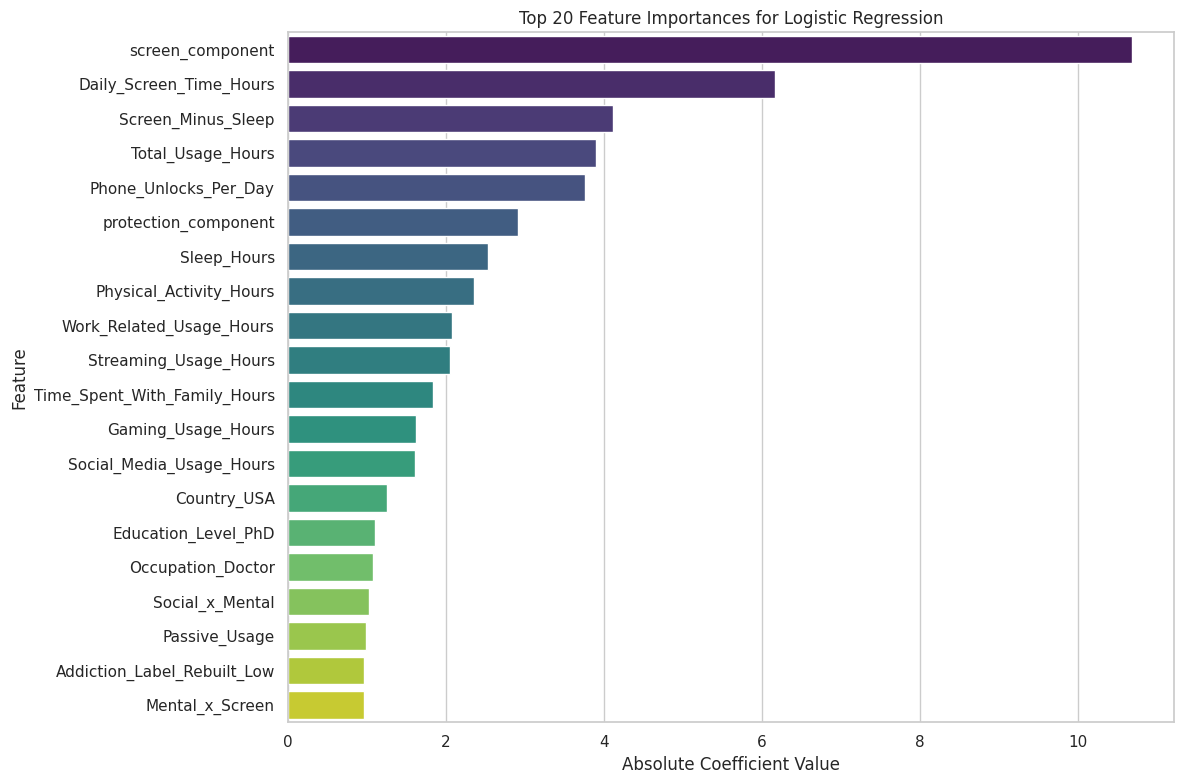

In [61]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis')
plt.title('Top 20 Feature Importances for Logistic Regression')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
y_pred = model.predict(X_test)

print("Model predictions on test data generated successfully.")

**Reasoning**:
With predictions now available (`y_pred`), the model's performance can be evaluated by comparing these predictions against the true labels (`y_test_encoded`). This will involve calculating accuracy, displaying a confusion matrix, and generating a classification report.



In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)

print("Model evaluation completed successfully.")

**Reasoning**:
To confirm the data has been preprocessed, I will print the type and shape of X_train_scaled, X_test_scaled, y_train_encoded, and y_test_encoded to ensure they are available and in the expected format (e.g., numpy arrays for scaled features and encoded targets).



In [ ]:
print(f"X_train type: {type(X_train)}, shape: {X_train.shape}")
print(f"X_test type: {type(X_test)}, shape: {X_test.shape}")
print(f"y_train type: {type(y_train)}, shape: {y_train.shape}")
print(f"y_test type: {type(y_test)}, shape: {y_test.shape}")

print("Confirmation of preprocessed data completion successful.")

Train and Evaluate Decision Tree Model




**Reasoning**:
To train and evaluate a Decision Tree Classifier as instructed, I will import the necessary model, instantiate it, train it on the scaled and encoded training data, make predictions on the scaled test data, and then calculate and print the accuracy, confusion matrix, and classification report.



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_conf_matrix = confusion_matrix(y_test, y_pred_dt)
dt_class_report = classification_report(y_test, y_pred_dt)

print("Decision Tree Classifier Trained and Evaluated Successfully.")
print(f"\nDecision Tree Accuracy: {dt_accuracy:.2f}")
print("\nDecision Tree Confusion Matrix:\n", dt_conf_matrix)
print("\nDecision Tree Classification Report:\n", dt_class_report)

### Hyperparameter Tuning for Decision Tree Classifier


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Define the parameter grid for Decision Tree Classifier
param_grid_dt = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 5, 10],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Instantiate GridSearchCV
grid_search_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search_dt.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters for Decision Tree Classifier:", grid_search_dt.best_params_)
print("Best cross-validation accuracy for Decision Tree Classifier:", grid_search_dt.best_score_)

# Get the best model
best_dt_model = grid_search_dt.best_estimator_

# Make predictions with the best model
y_pred_dt_tuned = best_dt_model.predict(X_test)

# Evaluate the best model
dt_tuned_accuracy = accuracy_score(y_test, y_pred_dt_tuned)
dt_tuned_conf_matrix = confusion_matrix(y_test, y_pred_dt_tuned)
dt_tuned_class_report = classification_report(y_test, y_pred_dt_tuned)

print(f"\nTuned Decision Tree Accuracy: {dt_tuned_accuracy:.2f}")
print("\nTuned Decision Tree Confusion Matrix:\n", dt_tuned_conf_matrix)
print("\nTuned Decision Tree Classification Report:\n", dt_tuned_class_report)


## Train and Evaluate Random Forest Model

### Subtask:
Implement and train a Random Forest Classifier, an ensemble method known for its robustness, on the preprocessed training data. Evaluate its predictions on the test set using standard classification metrics.


**Reasoning**:
To implement and evaluate a Random Forest Classifier as instructed, I will import the necessary model, instantiate it, train it on the scaled and encoded training data, make predictions on the scaled test data, and then calculate and print the accuracy, confusion matrix, and classification report.



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_conf_matrix = confusion_matrix(y_test, y_pred_rf)
rf_class_report = classification_report(y_test, y_pred_rf)

print("Random Forest Classifier Trained and Evaluated Successfully.")
print(f"\nRandom Forest Accuracy: {rf_accuracy:.2f}")
print("\nRandom Forest Confusion Matrix:\n", rf_conf_matrix)
print("\nRandom Forest Classification Report:\n", rf_class_report)

### Train and Evaluate Naive Bayes Model


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_conf_matrix = confusion_matrix(y_test, y_pred_nb)
nb_class_report = classification_report(y_test, y_pred_nb)

print("Gaussian Naive Bayes Classifier Trained and Evaluated Successfully.")
print(f"\nGaussian Naive Bayes Accuracy: {nb_accuracy:.2f}")
print("\nGaussian Naive Bayes Confusion Matrix:\n", nb_conf_matrix)
print("\nGaussian Naive Bayes Classification Report:\n", nb_class_report)

### Train and Evaluate Support Vector Machine (SVM) Model with Hyperparameter Tuning

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Define the parameter grid for SVM
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# Instantiate GridSearchCV
grid_search_svm = GridSearchCV(SVC(random_state=42), param_grid_svm, cv=3, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search_svm.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters for SVM:", grid_search_svm.best_params_)
print("Best cross-validation accuracy for SVM:", grid_search_svm.best_score_)

# Get the best model
best_svm_model = grid_search_svm.best_estimator_

# Make predictions with the best model
y_pred_svm_tuned = best_svm_model.predict(X_test)

# Evaluate the best model
svm_tuned_accuracy = accuracy_score(y_test, y_pred_svm_tuned)
svm_tuned_conf_matrix = confusion_matrix(y_test, y_pred_svm_tuned)
svm_tuned_class_report = classification_report(y_test, y_pred_svm_tuned)

print(f"\nTuned SVM Accuracy: {svm_tuned_accuracy:.2f}")
print("\nTuned SVM Confusion Matrix:\n", svm_tuned_conf_matrix)
print("\nTuned SVM Classification Report:\n", svm_tuned_class_report)


Instantiate the GaussianNB model,Train the model
Make predictions on the test data,Calculate evaluation metrics



### Train and Evaluate K-Nearest Neighbors (KNN) Model with Hyperparameter Tuning

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Define the parameter grid for KNN
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Instantiate GridSearchCV
grid_search_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search_knn.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters for KNN:", grid_search_knn.best_params_)
print("Best cross-validation accuracy for KNN:", grid_search_knn.best_score_)

# Get the best model
best_knn_model = grid_search_knn.best_estimator_

# Make predictions with the best model
y_pred_knn_tuned = best_knn_model.predict(X_test)

# Evaluate the best model
knn_tuned_accuracy = accuracy_score(y_test, y_pred_knn_tuned)
knn_tuned_conf_matrix = confusion_matrix(y_test, y_pred_knn_tuned)
knn_tuned_class_report = classification_report(y_test, y_pred_knn_tuned)

print(f"\nTuned KNN Accuracy: {knn_tuned_accuracy:.2f}")
print("\nTuned KNN Confusion Matrix:\n", knn_tuned_conf_matrix)
print("\nTuned KNN Classification Report:\n", knn_tuned_class_report)
